# **Object Localization**

## Planning

In [ ]:
"""
Input: Full Image
Output: Cropped Image

Metric of Success: Intersection over Union (IoU) for bounding box

Dataset: (NOTE: all transforms on the image have been removed)
X -> Full Image
y -> {source, bounding_box, category_id, style, etc.}

Components:
1. YOLO Model
2. Cropping images based on bounding boxes
"""

## Imports

In [ ]:
!pip install ultralytics
!pip install pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.6 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

import json
import pathlib
from pathlib import Path
from collections import defaultdict
import csv
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data.sampler import SubsetRandomSampler
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Dataset
import shutil

import PIL
from PIL import Image
import yaml

import io

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Data Loading & Conversion

In [ ]:
save_dir = "/content/yolo_data"
key_dir = "/content/class_keys"
os.makedirs(save_dir, exist_ok=True)
os.makedirs(key_dir, exist_ok=True)

output_dir = Path("/content/yolo_data/images/train")
output_dir.mkdir(parents=True, exist_ok=True)
output_dir = Path("/content/yolo_data/images/val")
output_dir.mkdir(parents=True, exist_ok=True)
output_dir = Path("/content/yolo_data/images/test")
output_dir.mkdir(parents=True, exist_ok=True)

output_dir = Path("/content/yolo_data/labels/train")
output_dir.mkdir(parents=True, exist_ok=True)
output_dir = Path("/content/yolo_data/labels/val")
output_dir.mkdir(parents=True, exist_ok=True)
output_dir = Path("/content/yolo_data/labels/test")
output_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
class ClothingDetectionDataset(Dataset):
    def __init__(self, img_dir, annos_dir, image_names, categories={1, 8}, transform=None):
        self.img_dir = img_dir
        self.annos_dir = annos_dir
        self.transform = transform
        self.image_names = image_names
        self.source_key = {
            'user': 0,
            'shop': 1
        }
        self.categories = categories

        self.image_files = []
        self.annos_files = []

        # Process all the images and annotations at initialization
        for img_name in self.image_names:
            img_path = os.path.join(self.img_dir, img_name)
            with open(img_path, "rb") as f:
                self.image_files.append(f.read())

            annos_path = os.path.join(self.annos_dir, img_name.replace('.jpg', '.json'))
            with open(annos_path) as f:
                self.annos_files.append(json.load(f))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        annotation = self.annos_files[idx]
        image_data = self.image_files[idx]
        image = Image.open(io.BytesIO(image_data)).convert('RGB')

        sources = []
        boxes = []
        categories = []
        styles = []
        pair_ids = []
        occlusions = []

        items = [annotation[k] for k in annotation.keys() if 'item' in k]
        for item in items:
            if item['category_id'] in self.categories:
                sources.append(self.source_key[annotation['source']])
                boxes.append(item['bounding_box'])
                categories.append(item['category_id'])
                styles.append(item['style'])
                pair_ids.append(annotation['pair_id'])
                occlusions.append(item['occlusion'])
            else:
                continue

        sources = torch.tensor(sources, dtype=torch.int64)
        boxes = torch.tensor(boxes, dtype=torch.float32)
        categories = torch.tensor(categories, dtype=torch.int64)
        styles = torch.tensor(styles, dtype=torch.int64)
        pair_ids = torch.tensor(pair_ids, dtype=torch.int64)
        occlusions = torch.tensor(occlusions, dtype=torch.int64)

        target = {
            "sources": sources,
            "boxes": boxes,
            "categories": categories,
            "styles": styles,
            "pair_ids": pair_ids,
            "occlusions": occlusions
        }

        if self.transform:
            image = self.transform(image)

        return image, target



In [ ]:
_ = !unzip "/content/Archive.zip" -d "/content/"

In [ ]:
# Load dataset file
import sys
project_root = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
sys.path.insert(0, project_root)
dataset_file = 'ml/data/version1/localization_dataset.pt'
localization_dataset = torch.load(dataset_file, map_location=device, weights_only=False)

In [ ]:
# Transform the data to work with YOLO

def create_dataset(dataset, output_dir='/content/yolo_data/', key_save_path="/content/class_keys", train_split=0.2, with_classes=False):

    class_info_key = collect_all_class_info(dataset, key_save_path, with_classes)

    # Split the dataset into train, val, and test
    dataset_size = len(dataset)
    train_size = int(0.8*dataset_size)
    val_test_size = int((dataset_size - train_size)/2)

    train_set, val_set, test_set = random_split(
        dataset,
        [train_size, val_test_size, val_test_size]
    )

    # Convert each dataset into YOLO formatting
    convert_to_YOLO(train_set, output_dir, class_info_key, split="train")
    convert_to_YOLO(val_set, output_dir, class_info_key, split="val")
    convert_to_YOLO(test_set, output_dir, class_info_key, split="test")

def collect_all_class_info(dataset, save_path, with_classes):

    save_path = Path(save_path)

    all_pairs = []

    for i in range(len(dataset)):
        image, target = dataset[i]
        boxes = target["boxes"]
        categories = target["categories"]
        styles = target["styles"]

        categories = [int(i) for i in categories]
        styles = [int(i) for i in styles]

        all_pairs.extend(zip(categories,styles))

    # Convert category/style to key
    unique_pairs = sorted(set(all_pairs))
    if with_classes:
        pair_to_class = {pair:i for i, pair in enumerate(unique_pairs)}
    else: # Single class case
        pair_to_class = {pair: 0 for i, pair in enumerate(unique_pairs)}

    # Save key to file for later reference
    with open(save_path / f"classkey.json", "w") as f:
        json.dump({f"{category}_{style}": class_key for (category, style), class_key in pair_to_class.items()}, f, indent=2)

    print(f"Class key mapping saved to {save_path}/classkey.json")
    print(f"Total unique classes: {len(pair_to_class)}")

    return pair_to_class


def convert_to_YOLO(dataset, output_dir, label_dict, split="train"):
    # Set the directories for saving
    images_dir = Path(output_dir) / "images" / split
    labels_dir = Path(output_dir) / "labels" / split

    # Loop through all items in the dataset
    for idx in range(len(dataset)):
        image, target = dataset[idx]

        width, height = image.size

        # Save image to file
        img_name = f"{idx:06d}.jpg"
        image.save(images_dir / img_name)

        # Adjust labels for YOLO (x,y,w,h)
        label_path = labels_dir / f"{idx:06d}.txt"
        with open(label_path, "w") as f:
            boxes = target["boxes"]
            categories = target["categories"]
            styles = target["styles"]

            categories = [int(i) for i in categories]
            styles = [int(i) for i in styles]

            for box, cat, style in zip(boxes, categories, styles):
                class_label = label_dict[(cat, style)]
                x1, y1, x2, y2 = box

                x_centre = (x1 + x2) / 2 / width
                y_centre = (y1 + y2) / 2 / height
                box_width = (x2 - x1) / width
                box_height = (y2 - y1) / height

                f.write(f"{class_label} {x_centre} {y_centre} {box_width} {box_height}\n")

    print(f"Conversion completed. Images saved in {images_dir}, labels saved in {labels_dir}")

#########################
# This is a modified version of the code above assuming we are just trying to detect clothing, not the clothing item type.
def convert_to_YOLO_single_class(dataset, output_dir, key_save_path="/content/class_keys/", split="train"):
    # Set the directories for saving
    images_dir = Path(output_dir) / "images" / split
    labels_dir = Path(output_dir) / "labels" / split

    # Loop through all items in the dataset
    for idx in range(len(dataset)):
        image, target = dataset[idx]
        width, height = image.size

        # Save image to file
        img_name = f"{idx:06d}.jpg"
        image.save(images_dir / img_name)

        # Adjust labels for YOLO (x,y,w,h)
        label_path = labels_dir / f"{idx:06d}.txt"
        with open(label_path, "w") as f:
            boxes = target["boxes"]

            for box in boxes:
                x1, y1, x2, y2 = box

                x_centre = (x1 + x2) / 2 / width
                y_centre = (y1 + y2) / 2 / height
                box_width = (x2 - x1) / width
                box_height = (y2 - y1) / height

                class_label = 0 # since only one class just "clothing"
                f.write(f"{class_label} {x_centre} {y_centre} {box_width} {box_height}\n")

    print(f"Conversion completed. Images saved in {images_dir}, labels saved in {labels_dir}")




In [ ]:
# Create the yaml file
class_key_file = "/content/class_keys/classkey.json"

def make_yaml_file(output_dir_yaml="/content/yolo_data", classkey=class_key_file, single_class=True):
    output_dir = Path(output_dir_yaml)

    if single_class:
        id_key = {0: "clothing"}
    else:
        with open(class_key_file) as f:
            classkey = json.load(f)
        id_key = {v: k.replace("_", "-") for k, v in classkey.items()}


    data = {
        "path": str(Path(output_dir_yaml).resolve()),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": id_key
        }
    with open(output_dir / "dataset.yaml", "w") as f:
        yaml.dump(data, f)

    print(f"Dataset yaml complete!")

In [ ]:
# Create the Datasets
create_dataset(localization_dataset)

# Create the yaml file
make_yaml_file()

In [ ]:
!zip -r yolo_data.zip /content/yolo_data

Streaming output truncated to the last 5000 lines.
  adding: content/yolo_data/labels/test/000050.txt (deflated 27%)
  adding: content/yolo_data/labels/test/000185.txt (deflated 28%)
  adding: content/yolo_data/labels/test/000362.txt (deflated 29%)
  adding: content/yolo_data/labels/test/000139.txt (deflated 48%)
  adding: content/yolo_data/labels/test/000101.txt (deflated 40%)
  adding: content/yolo_data/labels/test/000439.txt (deflated 41%)
  adding: content/yolo_data/labels/test/000414.txt (deflated 30%)
  adding: content/yolo_data/labels/test/000370.txt (deflated 28%)
  adding: content/yolo_data/labels/test/000025.txt (deflated 28%)
  adding: content/yolo_data/labels/test/000152.txt (deflated 26%)
  adding: content/yolo_data/labels/test/000295.txt (deflated 24%)
  adding: content/yolo_data/labels/test/000225.txt (deflated 19%)
  adding: content/yolo_data/labels/test/000356.txt (deflated 40%)
  adding: content/yolo_data/labels/test/000329.txt (deflated 27%)
  adding: content/yolo_da

## Loading Yolo Zip



In [ ]:
_ = !unzip "/content/yolo_data.zip" -d "/"

## Training YOLO

In [ ]:
# Initial test run
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 5,
    imgsz=224,
    batch=32
)

# There are three different outputs in Ultralytics which are model.train() (training results),
# model.val() mAP, and other similar metrics, and # model("img_file_name.jpg") which provides the bounded box information
metrics = model.val()
#print(metrics.box.map) # this prints mAP50-95
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,


0: 224x224 2 clothings, 54.8ms
1: 224x224 1 clothing, 54.8ms
2: 224x224 1 clothing, 54.8ms
3: 224x224 2 clothings, 54.8ms
Speed: 1.3ms preprocess, 54.8ms inference, 0.8ms postprocess per image at shape (1, 3, 224, 224)
Results saved to /content/runs/detect/predict


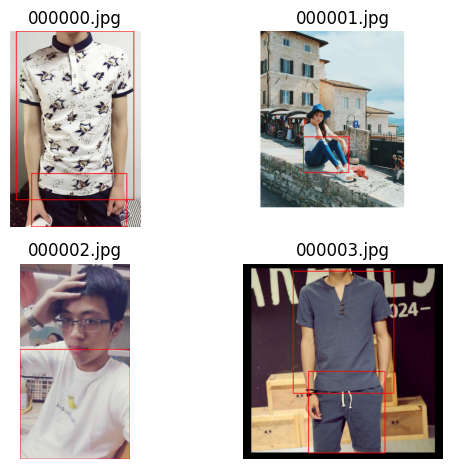

In [ ]:
from IPython.display import Image, display
import matplotlib.pyplot as plt
import cv2


test_dir = Path("/content/yolo_data/images/test")
image_paths = sorted(test_dir.glob("*.jpg"))[:4]

# Make predictions from test images
test_results = model.predict(source=image_paths, save=True, conf=0.25)

def visualize_results(results, grid_size=(2,2)):
    # Retrieve predictions and display
    fig, axes = plt.subplots(grid_size[0], grid_size[1])
    axes = axes.flatten()

    for ax, result, img_path in zip(axes, results, image_paths):
        # Load image
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Draw predicted boxes
        for box in result.boxes.xyxy:
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

        ax.imshow(img)
        ax.set_title(img_path.name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## Tuning Yolo

In [ ]:
# Hyperparameter Tuning
# Params: Epochs, Batch Size, lr0, lrf, momentum, weight decay
# Note: De-emphasize class importance with cls, emphasize bbox with dfl

### Test 0

In [ ]:
# Test #0 v1 (copying input from auto optimizer)
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 5,
    imgsz=224,
    batch=32,
    optimizer= 'AdamW',
    cos_lr=False,
    lr0=0.002,
    lrf=0.01,
    momentum = 0.9
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.9, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.0,

In [ ]:
# Test #1 v2 (copying input from auto optimizer)
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 5,
    imgsz=224,
    batch=32,
    optimizer= 'AdamW',
    cos_lr=False,
    lr0=0.002,
    lrf=0.01,
    momentum = 0.9
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.9, mosaic=1.0, multi_scale=0.0, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.0,

### Test 1 (Changing cos_lr)

In [ ]:
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 5,
    imgsz=224,
    batch=32,
    optimizer= 'AdamW',
    cos_lr=True,
    lr0=0.002,
    lrf=0.01,
    momentum = 0.9
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.9, mosaic=1.0, multi_scale=0.0, name=train6, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.0, 

### Test 2 (Changing to SGD)

In [ ]:
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 5,
    imgsz=224,
    batch=32,
    optimizer= 'SGD',
    cos_lr=False,
    lr0=0.002,
    lrf=0.01,
    momentum = 0.9
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.9, mosaic=1.0, multi_scale=0.0, name=train7, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=100, perspective=0.0, p

### Test 3 (Changing Batch Size)

In [ ]:
# Test #3 v1 Lowering Batch Size
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 5,
    imgsz=224,
    batch=16,
    optimizer= 'AdamW',
    cos_lr=False,
    lr0=0.002,
    lrf=0.01,
    momentum = 0.9
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.9, mosaic=1.0, multi_scale=0.0, name=train8, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.0,

In [ ]:
# Test #3 v2 Increasing Batch Size
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 5,
    imgsz=224,
    batch=64,
    optimizer= 'AdamW',
    cos_lr=False,
    lr0=0.002,
    lrf=0.01,
    momentum = 0.9
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.9, mosaic=1.0, multi_scale=0.0, name=train9, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.0,

### Test 4 (Changing Learning Rate Initial)

In [ ]:
# Test #4 v1 Increasing LR0
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 5,
    imgsz=224,
    batch=32,
    optimizer= 'AdamW',
    cos_lr=False,
    lr0=0.005,
    lrf=0.01,
    momentum = 0.9
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.9, mosaic=1.0, multi_scale=0.0, name=train10, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.0

In [ ]:
# Test #4 v2 Lowering LR0
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 5,
    imgsz=224,
    batch=32,
    optimizer= 'AdamW',
    cos_lr=False,
    lr0=0.0005,
    lrf=0.01,
    momentum = 0.9
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.9, mosaic=1.0, multi_scale=0.0, name=train11, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.

In [ ]:
# Test #4 v3 Increasing LRF
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 5,
    imgsz=224,
    batch=32,
    optimizer= 'AdamW',
    cos_lr=False,
    lr0=0.002,
    lrf=0.1,
    momentum = 0.9
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.9, mosaic=1.0, multi_scale=0.0, name=train12, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.0,

In [ ]:
# Test #4 v4 Lowering LRF
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 5,
    imgsz=224,
    batch=32,
    optimizer= 'AdamW',
    cos_lr=False,
    lr0=0.002,
    lrf=0.005,
    momentum = 0.9
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.005, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.9, mosaic=1.0, multi_scale=0.0, name=train13, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.

### Test #5 (Changing Momentum)

In [ ]:
# Test #5 v1 Lowering Momentum
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 5,
    imgsz=224,
    batch=32,
    optimizer= 'AdamW',
    cos_lr=False,
    lr0=0.002,
    lrf=0.01,
    momentum = 0.8
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.8, mosaic=1.0, multi_scale=0.0, name=train14, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.0

In [ ]:
# Test #5 v2 Increasing Momentum
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 5,
    imgsz=224,
    batch=32,
    optimizer= 'AdamW',
    cos_lr=False,
    lr0=0.002,
    lrf=0.01,
    momentum = 0.95
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.95, mosaic=1.0, multi_scale=0.0, name=train15, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.

### Test #6 (Combining All Parameters)

In [ ]:
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 5,
    imgsz=224,
    batch=16,
    optimizer= 'AdamW',
    cos_lr=False,
    lr0=0.0005,
    lrf=0.01,
    momentum = 0.8
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.8, mosaic=1.0, multi_scale=0.0, name=train16, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.

In [ ]:
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 5,
    imgsz=224,
    batch=16,
    optimizer= 'AdamW',
    cos_lr=True,
    lr0=0.0005,
    lrf=0.01,
    momentum = 0.8
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.8, mosaic=1.0, multi_scale=0.0, name=train17, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.0

In [ ]:
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 5,
    imgsz=224,
    batch=16,
    optimizer= 'AdamW',
    cos_lr=False,
    lr0=0.0005,
    lrf=0.005,
    momentum = 0.8
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.005, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.8, mosaic=1.0, multi_scale=0.0, name=train18, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0

In [ ]:
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 5,
    imgsz=224,
    batch=16,
    optimizer= 'AdamW',
    cos_lr=True,
    lr0=0.00075,
    lrf=0.01,
    momentum = 0.8
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00075, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.8, mosaic=1.0, multi_scale=0.0, name=train19, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.

In [ ]:
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 5,
    imgsz=224,
    batch=16,
    optimizer= 'AdamW',
    cos_lr=False,
    lr0=0.0005,
    lrf=0.01,
    momentum = 0.85
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.85, mosaic=1.0, multi_scale=0.0, name=train20, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0

In [ ]:
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 5,
    imgsz=224,
    batch=16,
    optimizer= 'AdamW',
    cos_lr=False,
    lr0=0.0005,
    lrf=0.01,
    momentum = 0.7
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.7, mosaic=1.0, multi_scale=0.0, name=train21, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.

In [ ]:
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 5,
    imgsz=224,
    batch=16,
    optimizer= 'AdamW',
    cos_lr=True,
    lr0=0.0005,
    lrf=0.01,
    momentum = 0.85
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.85, mosaic=1.0, multi_scale=0.0, name=train22, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.

In [ ]:
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 5,
    imgsz=224,
    batch=16,
    optimizer= 'AdamW',
    cos_lr=True,
    lr0=0.0005,
    lrf=0.01,
    momentum = 0.9
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.9, mosaic=1.0, multi_scale=0.0, name=train23, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.0

In [ ]:
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 5,
    imgsz=224,
    batch=20,
    optimizer= 'AdamW',
    cos_lr=True,
    lr0=0.0005,
    lrf=0.01,
    momentum = 0.85
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=20, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.85, mosaic=1.0, multi_scale=0.0, name=train24, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.

In [ ]:
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 15,
    imgsz=224,
    batch=20,
    optimizer= 'AdamW',
    cos_lr=True,
    lr0=0.0005,
    lrf=0.01,
    momentum = 0.85
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=20, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.85, mosaic=1.0, multi_scale=0.0, name=train25, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0

In [ ]:
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 30,
    imgsz=224,
    batch=20,
    optimizer= 'AdamW',
    cos_lr=True,
    lr0=0.0005,
    lrf=0.01,
    momentum = 0.85
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=20, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.85, mosaic=1.0, multi_scale=0.0, name=train26, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0

In [ ]:
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 15,
    imgsz=224,
    batch=20,
    optimizer= 'AdamW',
    cos_lr=True,
    lr0=0.0005,
    lrf=0.005,
    momentum = 0.85
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=20, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.005, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.85, mosaic=1.0, multi_scale=0.0, name=train27, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=

In [ ]:
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 30,
    imgsz=224,
    batch=20,
    optimizer= 'AdamW',
    cos_lr=True,
    lr0=0.0003,
    lrf=0.001,
    momentum = 0.85
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=20, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0003, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.85, mosaic=1.0, multi_scale=0.0, name=train28, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=

In [ ]:
model = YOLO("yolov8n.pt")
model.train(
    data="./yolo_data/dataset.yaml",
    epochs = 60,
    imgsz=224,
    batch=20,
    optimizer= 'AdamW',
    cos_lr=True,
    lr0=0.0005,
    lrf=0.01,
    momentum = 0.85
)


metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=20, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=./yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.85, mosaic=1.0, multi_scale=0.0, name=train29, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0

## Testing Data Outcome


In [ ]:
model = YOLO("/content/runs/detect/train29/weights/best.pt")

metrics = model.val(
    data="./yolo_data/dataset.yaml",
    split="test"
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1029.7±396.2 MB/s, size: 63.7 KB)
val: Scanning /content/yolo_data/labels/test.cache... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 139.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 8.5it/s 3.8s
                   all        500        746      0.937      0.953      0.981      0.844
Speed: 0.2ms preprocess, 1.3ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/val31
Precision: 0.9367766649655931
Recall: 0.9533693984236115
mAP50: 0.9809101330896315
mAP50-95: 0.8435080489336484


In [ ]:
model = YOLO("/content/runs/detect/train25/weights/best.pt")

metrics = model.val(
    data="./yolo_data/dataset.yaml",
    split="test"
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 22.0±17.7 MB/s, size: 63.7 KB)
val: Scanning /content/yolo_data/labels/test... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 781.0it/s 0.6s
val: New cache created: /content/yolo_data/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 9.5it/s 3.4s
                   all        500        746      0.928      0.937      0.974      0.819
Speed: 0.3ms preprocess, 1.2ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val25
Precision: 0.9283222545196814
Recall: 0.9374962732251859
mAP50: 0.9739778157579682
mAP50-95: 0.818827573738886


In [ ]:
model = YOLO("/content/runs/detect/train30/weights/best.pt")

metrics = model.val(
    data="./yolo_data/dataset.yaml",
    split="test"
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

## Image Processing

In [ ]:
"""
Prediction w/ YOLO:
https://docs.ultralytics.com/modes/predict/#key-features-of-predict-mode

Use result = model(["image.jpg]) to make prediction - call result.boxes to retrieve bbox
"""
results = model(["/content/yolo_data/images/val/000001.jpg"])
result = results[0]
boxes = result.boxes.xyxy.cpu().numpy()
#classes = result.boxes.cls.cpu().numpy()
#print(result)
print(f"boxes: {boxes}")
#print(f"classes: {classes}")



0: 160x224 2 clothings, 40.8ms
Speed: 0.9ms preprocess, 40.8ms inference, 1.3ms postprocess per image at shape (1, 3, 160, 224)
boxes: [[     239.93      148.57      388.56      341.07]
 [     259.39      314.18      368.24      423.35]]


In [ ]:
save_dir = "/content/cropped_data"
#key_dir = "/content/class_keys"
os.makedirs(save_dir, exist_ok=True)
#os.makedirs(key_dir, exist_ok=True)

output_dir = Path("/content/cropped_data/images/train")
output_dir.mkdir(parents=True, exist_ok=True)
output_dir = Path("/content/cropped_data/images/val")
output_dir.mkdir(parents=True, exist_ok=True)
output_dir = Path("/content/cropped_data/images/test")
output_dir.mkdir(parents=True, exist_ok=True)

output_dir = Path("/content/cropped_data/labels/train")
output_dir.mkdir(parents=True, exist_ok=True)
output_dir = Path("/content/cropped_data/labels/val")
output_dir.mkdir(parents=True, exist_ok=True)
output_dir = Path("/content/cropped_data/labels/test")
output_dir.mkdir(parents=True, exist_ok=True)


def YOLO_to_crop_info(input_dir, output_dir, split):
  img_num = 0
  folder_path = os.path.join(input_dir, split)

  # looping through 1 file at a time
  for file in os.listdir(folder_path):

    img_path = os.path.join(folder_path, file)
    #label_path = os.path.join(output_dir, "labels", split, file)
    img = Image.open(img_path).convert("RGB")
    results = model(img_path)
    result = results[0]
    boxes = result.boxes.xyxy.cpu().numpy()

    # looping through all bounding boxed in an image, can be multiple results per file (multiple items of clothing)

    for box in boxes:
      img_num += 1
      x1,y1,x2,y2 = box
      cropped_img = img.crop((x1, y1, x2, y2))

      # Saving the img file
      output_name = f"{img_num}.jpg"
      output_path = os.path.join(output_dir, "images", split, output_name)
      cropped_img.save(output_path)

      # Saving the label file
      #output_name = f"{img_num}.jpg"
      #output_path = os.path.join(output_dir, "labels", split, output_name)

  print("Cropping Completed")





In [ ]:
folder_path = "/content/yolo_data/images"
output_dir = "/content/cropped_data"

YOLO_to_crop_info(folder_path, output_dir, "train")
YOLO_to_crop_info(folder_path, output_dir, "val")
YOLO_to_crop_info(folder_path, output_dir, "test")

Streaming output truncated to the last 5000 lines.
Speed: 0.8ms preprocess, 12.1ms inference, 7.0ms postprocess per image at shape (1, 3, 224, 192)

image 1/1 /content/yolo_data/images/train/000874.jpg: 224x224 4 clothings, 16.0ms
Speed: 0.9ms preprocess, 16.0ms inference, 1.6ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/yolo_data/images/train/000171.jpg: 224x160 2 clothings, 40.4ms
Speed: 0.7ms preprocess, 40.4ms inference, 3.4ms postprocess per image at shape (1, 3, 224, 160)

image 1/1 /content/yolo_data/images/train/001963.jpg: 224x160 2 clothings, 7.7ms
Speed: 0.8ms preprocess, 7.7ms inference, 1.2ms postprocess per image at shape (1, 3, 224, 160)

image 1/1 /content/yolo_data/images/train/000787.jpg: 224x160 1 clothing, 9.2ms
Speed: 0.7ms preprocess, 9.2ms inference, 1.2ms postprocess per image at shape (1, 3, 224, 160)

image 1/1 /content/yolo_data/images/train/002112.jpg: 224x160 2 clothings, 8.3ms
Speed: 1.1ms preprocess, 8.3ms inference, 1.6ms postpro

In [ ]:
import hashlib
import cv2

class ClothingLocalization():
    def __init__(self, model_loc="/content/best.pt", uploaded_img_dir="/content/uploaded_images", save_dir="/content/cropped_data"):

        # Load the desired trained YOLO model
        self.model = YOLO(model_loc)

        # Uploaded images will be stored in this directory
        self.uploaded_img_dir = uploaded_img_dir
        os.makedirs(self.uploaded_img_dir, exist_ok=True)

        # Directory to save cropped images
        self.save_dir = save_dir
        os.makedirs(self.save_dir, exist_ok=True)

        # Create image cache
        self.img_cache = {}

    def hash_img(self, img_object):
        return hashlib.sha256(img_object).hexdigest()

    def preprocess_image(self, image):
        image = np.array(image)
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

        h, w = image.shape[:2]

        scale = min(224/h, 224/w)
        new_w = int(w*scale)
        new_h = int(h*scale)

        resized_img = cv2.resize(image, (new_w, new_h))

        # Add padding around the image
        canvas = np.full((224, 224, 3), 114, dtype=np.uint8)
        x_offset = (224 - new_w) // 2
        y_offset = (224 - new_h) // 2
        canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized_img

        return canvas

    def process_image(self, img_path):

        # Load image and make sure it is correct dimensions for model (224x224)
        img = Image.open(img_path).convert("RGB")
        img = self.preprocess_image(img)

        results = self.model(img)
        result = results[0]
        boxes = result.boxes.xyxy.cpu().numpy()


        h,w = img.shape[:2]
        cropped_images = []

        for box in boxes:
            x1, y1, x2, y2 = box
            x1 = int(max(0, x1))
            y1 = int(max(0, y1))
            x2 = int(min(w, x2))
            y2 = int(min(h, y2))
            if x2 > x1 and y2 > y1:
                cropped_img = img[y1:y2, x1:x2]
                cropped_images.append(cropped_img)

        return cropped_images

    def upload_image(self, img_object):
        img_object.seek(0)
        img = img_object.read()
        img_hash = self.hash_img(img)

        # Check if image has already been processed
        if img_hash in self.img_cache:
            print("Image already processed. Retrieving from cache.")
            return self.img_cache[img_hash]
        else:
            # Save the uploaded image to the directory
            img_name = f"{img_hash}.jpg"
            img_path = os.path.join(self.uploaded_img_dir, img_name)
            with open(img_path, "wb") as f:
                f.write(img)

            # Process the image and get cropped results
            cropped_images = self.process_image(img_path)

            # Save cropped images and update cache
            cropped_paths = []
            for i, cropped_img in enumerate(cropped_images):
                cropped_name = f"{img_hash}_crop_{i}.jpg"
                cropped_path = os.path.join(self.save_dir, cropped_name)
                cv2.imwrite(cropped_path, cropped_img)
                cropped_paths.append(cropped_path)

            self.img_cache[img_hash] = cropped_paths

            return cropped_paths

In [ ]:
cl = ClothingLocalization()
with open("/content/test_img.jpg", "rb") as f:
    paths = cl.upload_image(f)


0: 224x224 2 clothings, 57.8ms
Speed: 1.1ms preprocess, 57.8ms inference, 1.2ms postprocess per image at shape (1, 3, 224, 224)


In [ ]:
paths

['/content/cropped_data/5e8ff4c0b5b6f605ddb24e85fbefd9ad463d27289c6011f7198a9a61476a485a_crop_0.jpg',
 '/content/cropped_data/5e8ff4c0b5b6f605ddb24e85fbefd9ad463d27289c6011f7198a9a61476a485a_crop_1.jpg']